In [1]:
import sys
sys.path.append('../')

In [2]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol
import importlib

In [3]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [4]:
from qrisp.operators import X, Y, Z

def TFIM_qr(J,h,n_qubits):
    H = 0
    for i in range(n_qubits):
        i_next = (i+1)%n_qubits
        H += J*Z(i)*Z(i_next) + h*X(i)
    return H

def H_0(J,n_qubits):
    H = 0
    for i in range(0,n_qubits,2):
        H += J*Z(i)*Z((i+1)%n_qubits)
    return H

def H_1(J,n_qubits):
    H = 0
    for i in range(1,n_qubits,2):
        H += J*Z(i)*Z((i+1)%n_qubits)
    return H

def H_2(h,n_qubits):
    H = 0
    for i in range(n_qubits):
        H += h*X(i)
    return H

/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [13]:
from qrisp.vqe import VQEProblem
from qrisp import QuantumVariable,x
from qrisp import h as h_gate

n_qubits=8
J=1
h=0.5
H = TFIM_qr(J,h,n_qubits)

print('Computing Eigs')
EH,VH = np.linalg.eigh(H.to_array())
psigs=VH[:,0:1]
E_gs=EH[0]

def exp_H(qv,t):
    # Applies 5 Trotter steps of the Hamiltonian evolution
    H.trotterization(method='commuting')(qv, t, 1)

def ansatz_hva(qv,params):
    # HVA ansatz with 3 parameters, one for each term of the Hamiltonian
    H_0(J,n_qubits).trotterization(method='commuting')(qv, t=params[0])
    H_1(J,n_qubits).trotterization(method='commuting')(qv, t=params[1])
    H_2(h,n_qubits).trotterization(method='commuting')(qv, t=params[2])

def init_function(qv):
    for i in range(0,n_qubits,2):
        x(qv[i])


def U_0(qv):
    pass

HVA = VQEProblem(H,ansatz_hva,3,init_function=U_0)
U_HVA = HVA.train_function(QuantumVariable(n_qubits),depth=1,max_iter=100)

def state_prep_hva():
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    return qv


Computing Eigs


In [48]:
# Inspect VQE training and produced circuit
from run_qite import get_statevector
import inspect

print('HVA type:', type(HVA))
candidates = ['opt_result','opt_params','optimal_parameters','result','params','best_params','theta','optimal_theta']
for name in candidates:
    if hasattr(HVA, name):
        print(f'HVA.{name}:', getattr(HVA, name))

print('U_HVA callable:', callable(U_HVA))
try:
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    qc = qv.qs.compile()
    print('Compiled HVA circuit ops:', qc.count_ops())
    print('Circuit depth:', qc.depth())
    sv = get_statevector(qc, n_qubits)
    print('HVA fidelity to ground state:', fidelity_pure(psigs, sv.reshape(-1,1)))
except Exception as e:
    print('Error inspecting U_HVA:', e)

# Show some metadata about the returned train function (closure types)
try:
    if hasattr(U_HVA, '__closure__') and U_HVA.__closure__:
        print('U_HVA closure types:', [type(c.cell_contents) for c in U_HVA.__closure__])
    print('U_HVA source available:', hasattr(U_HVA, '__code__'))
except Exception:
    pass


HVA type: <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>
U_HVA callable: True
Compiled HVA circuit ops: {'cx': 16, 'rz': 16, 'h': 16}
Circuit depth: 9
HVA fidelity to ground state: 0.010186034744754652                              
U_HVA closure types: [<class 'int'>, <class 'numpy.ndarray'>, <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>]
U_HVA source available: True


In [49]:
from run_qite import run_QITE

s_values = np.linspace(0.01, 1.5, 20)
steps = 5
results = []
results.append(run_QITE(H, U_HVA, exp_H, s_values, steps,use_statevectors=True))
results.append(run_QITE(H, U_0, exp_H, s_values, steps,use_statevectors=True))

Simulating 8 qubits.. |                                                 | [  0%]

Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     
Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     


In [50]:
import pickle
with open(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps}_DBF_results.pkl', 'wb') as f:
    pickle.dump(results, f)


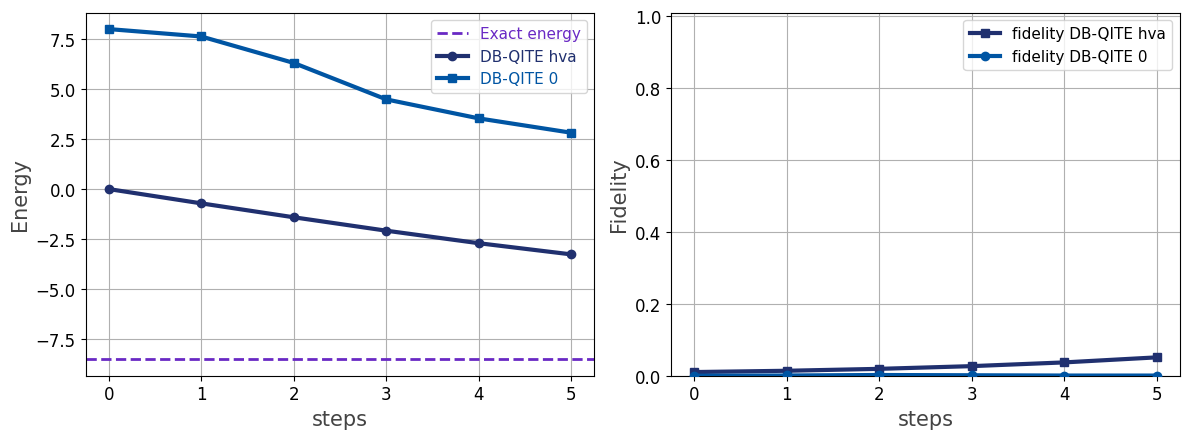

In [53]:
import matplotlib.pyplot as plt
import numpy as np

fidelities_hva = [fidelity_pure(psigs, results[0]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fidelities_0 = [fidelity_pure(psigs, results[1]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps+1), results[0]['optimal_energies'], c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE hva')
ax1.plot(range(steps+1), results[1]['optimal_energies'], c='#0055a3', marker='s', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE 0')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps+1), fidelities_hva, c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE hva')
ax2.plot(range(steps+1), fidelities_0, c='#0055a3', marker='o', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE 0')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps}_DBF_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
import Hamiltonian as ham
import Evolution as evol
from run_qite import get_statevector

H_acq,H_trot=ham.TFIM(J,h,n_qubits,T=2)

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))

qc_hva = state_prep_hva().qs.compile()
psi_0_hva = sp.csc_matrix(get_statevector(qc_hva,n_qubits).reshape(-1,1))

#QITE and ACQ evolution
D=4
dt = 0.1
N = 20

In [15]:

print("Computing ACQ")
E_ACQ_hva,psi_ACQ_hva,indx_acq_hva,times_acq_hva,a_acq_hva = evol.ACQ(n_qubits,H_acq,H_trot,D,psi_0_hva,N,dt,methodLS='LU')
E_ACQ_0,psi_ACQ_0,indx_acq_0,times_acq_0,a_acq_0 = evol.ACQ(n_qubits,H_acq,H_trot,D,psi_0,32,dt,methodLS='LU')

Computing ACQ
Using General Pauli Strings
Computing U at step 0
Computing U at step 5
Computing U at step 8
Computing U at step 11
Computing U at step 15
Computing U at step 18
Using Real Pauli Strings
Computing U at step 0
Computing U at step 15
Computing U at step 18
Computing U at step 22
Computing U at step 26
Computing U at step 30


In [16]:
import PauliStrings as ps
import run_qite
importlib.reload(run_qite)
from run_qite import build_acq_circuit_qrisp

num_paulis_real,PD_real,fail_real = ps.real(H_trot,D,n_qubits,PDstr=True)
num_paulis_gen,PD_gen,fail_gen = ps.general(H_trot,D,n_qubits,PDstr=True)
circuit_ops_0 = {}
circuits_0 = {}

steps_acq_0 = len(a_acq_0)
steps_acq_hva = len(a_acq_hva)


In [21]:
len(E_ACQ_0[indx_acq_0])

6

In [67]:
importlib.reload(run_qite)
from run_qite import build_acq_circuit_qrisp

for step in range(steps_acq_0+1): 
    qc = build_acq_circuit_qrisp(n_qubits,D,2,PD_real,a_acq_0,times_acq_0,step,U_0,debug=False)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_0[step] = qc
    circuit_ops_0[step] = tqc.count_ops()
    print(f"Step {step}: {tqc.count_ops()}")


circuit_data_0 = {
    'circuits': circuits_0,
    'circuit_ops': circuit_ops_0
}

circuit_ops_hva = {}
circuits_hva = {}

for step_acq in range(steps_acq_hva+1):
    qc = build_acq_circuit_qrisp(n_qubits,D,2,PD_gen,a_acq_hva,times_acq_hva,step_acq,U_HVA,debug=False)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_hva[step_acq] = qc
    circuit_ops_hva[step_acq] = tqc.count_ops()
    print(f"Step {step_acq}: {tqc.count_ops()}")

circuit_data_hva = {
    'circuits': circuits_hva,
    'circuit_ops': circuit_ops_hva
}

circuit_data_acq = {
    '0': circuit_data_0,
    'hva': circuit_data_hva
}

Step 0: {}
Step 1: {'u3': 889, 'cz': 1007}
Step 2: {'u3': 2520, 'cz': 2838}
Step 3: {'u3': 4151, 'cz': 4671}
Step 4: {'u3': 5799, 'cz': 6506}
Step 5: {'u3': 7438, 'cz': 8345}
Step 6: {'u3': 9083, 'cz': 10181}
Step 0: {'u3': 26, 'cz': 16}
Step 1: {'u3': 3255, 'cz': 3459}
Step 2: {'u3': 6973, 'cz': 7502}
Step 3: {'u3': 10698, 'cz': 11544}
Step 4: {'u3': 14456, 'cz': 15612}
Step 5: {'u3': 18207, 'cz': 19682}
Step 6: {'u3': 21956, 'cz': 23767}


In [ ]:
import pickle
with open(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq_0}_ACQ_D{D}_results.pkl', 'wb') as f:
    pickle.dump(circuit_data_acq, f)

In [10]:
import pickle
with open(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{6}_ACQ_D{D}_results.pkl', 'rb') as f:
    circuit_data_acq = pickle.load(f)

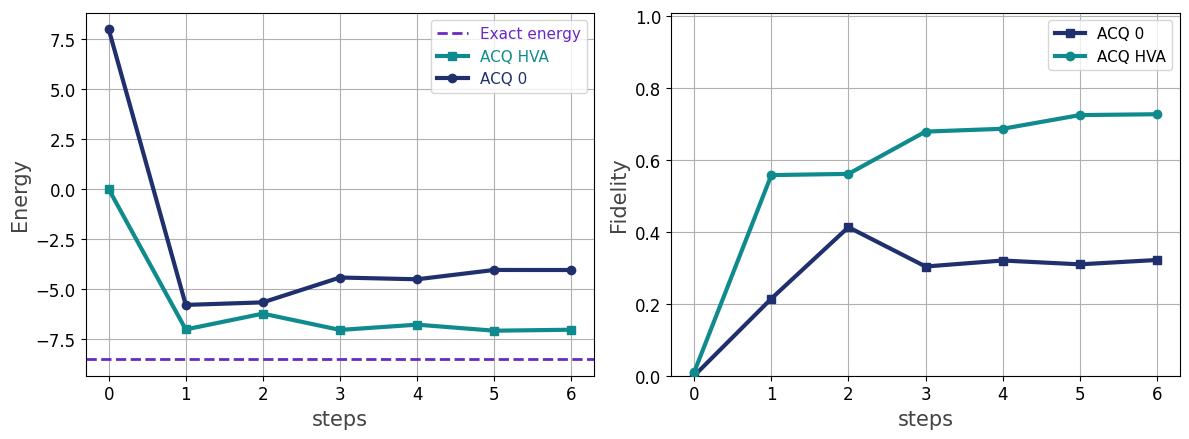

In [69]:
from run_qite import get_statevector,compute_moments

energies_acq_0 = [compute_moments(get_statevector(circuit_data_acq['0']['circuits'][step],n_qubits),H_acq)[0] for step in range(steps_acq_0+1)]
fidelities_acq_0 = [fidelity_pure(psigs, get_statevector(circuit_data_acq['0']['circuits'][step],n_qubits).reshape(-1,1)) for step in range(steps_acq_0+1)]

energies_acq_hva = [compute_moments(get_statevector(circuit_data_acq['hva']['circuits'][step],n_qubits),H_acq)[0] for step in range(steps_acq_hva+1)]
fidelities_acq_hva = [fidelity_pure(psigs, get_statevector(circuit_data_acq['hva']['circuits'][step],n_qubits).reshape(-1,1)) for step in range(steps_acq_hva+1)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps_acq_hva+1), energies_acq_hva, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax1.plot(range(steps_acq_0+1), energies_acq_0, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ 0')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps_acq_0+1), fidelities_acq_0, c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ 0')
ax2.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='#0f8b8d', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq_0}_ACQ_D{D}_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


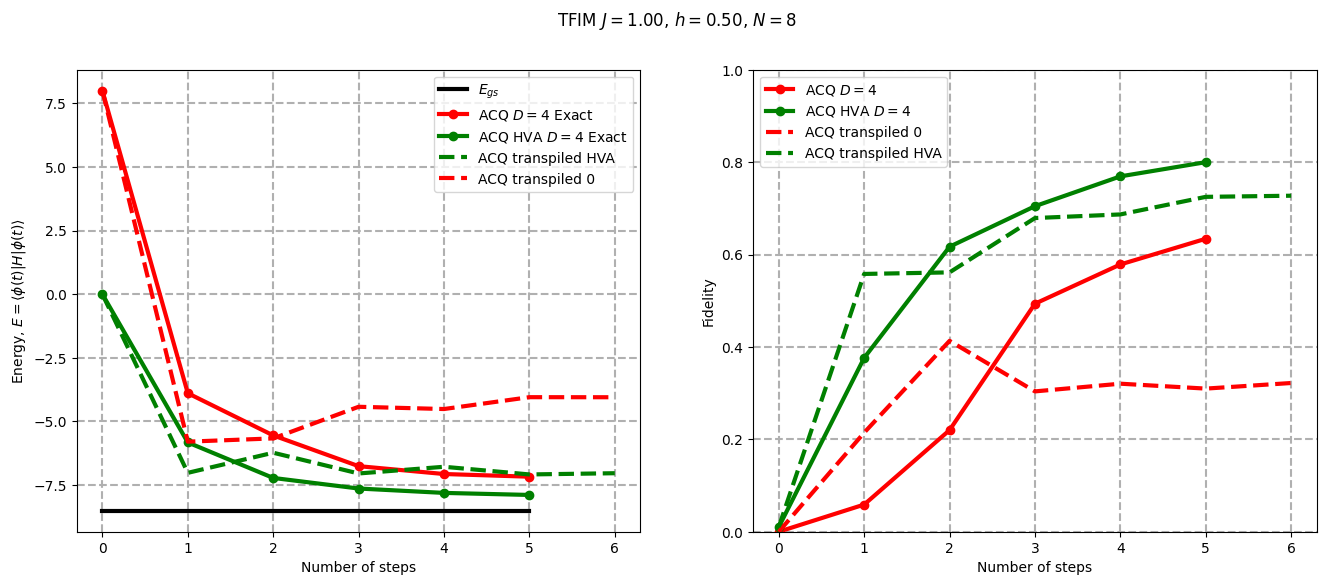

In [82]:
F_ACQ_0=np.zeros(32+1)
for i in range(32+1):
    F_ACQ_0[i]=fidelity_pure(psigs,psi_ACQ_0[:,i].todense())

F_ACQ_hva=np.zeros(N+1)
for i in range(N+1):
    F_ACQ_hva[i]=fidelity_pure(psigs,psi_ACQ_hva[:,i].todense())

plt.figure(figsize=(16, 6))

plt.suptitle("TFIM $J=%.2f$, $h=%.2f$, $N=%d$"%(J,h,n_qubits))
plt.subplot(1,2,1)
plt.plot(range(steps_acq_0),[E_gs]*steps_acq_0,'-k',linewidth=3,label='$E_{gs}$')
plt.plot(range(steps_acq_0),E_ACQ_0[indx_acq_0],'-ro',linewidth=3,label='ACQ $D=%d$ Exact'%D)
plt.plot(range(steps_acq_hva),E_ACQ_hva[indx_acq_hva],'-go',linewidth=3,label='ACQ HVA $D=%d$ Exact'%D)
plt.plot(range(steps_acq_hva+1), energies_acq_hva, c='g', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled HVA')
plt.plot(range(steps_acq_0+1), energies_acq_0, c='r', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled 0')

plt.xlabel("Number of steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
#plt.yticks(np.arange(-12, 10, step=4))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


plt.subplot(1,2,2)
plt.plot(range(len(indx_acq_0)),F_ACQ_0[indx_acq_0],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.plot(range(len(indx_acq_hva)),F_ACQ_hva[indx_acq_hva],'-go',linewidth=3,label='ACQ HVA $D=%d$'%D)
plt.plot(range(steps_acq_0+1), fidelities_acq_0, c='r', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled 0')
plt.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='g', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled HVA')
plt.xlabel("Number of steps")
plt.ylabel("Fidelity")
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)

plt.savefig(f'EXACT_VS_TRANSPILED_TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq_0}_ACQ_D{D}_results.png', dpi=300, bbox_inches='tight')
